## FASE 1 - BUSINESS UNDERSTANDING

**🎯 Latar Belakang :**  
Dalam industri retail, memahami pola penjualan sangat penting untuk membantu pengambilan keputusan bisnis, seperti pengelolaan stok dan strategi pemasaran.

**❓Permasalahan :**  
Bagaimana memprediksi penjualan di masa depan berdasarkan data historis yang tersedia?

**🎯 Tujuan :**  
Membangun model forecasting untuk memprediksi penjualan di masa depan menggunakan metode time series.

**📈 Manfaat :**
1. Membantu pengelolaan stok barang
2. Mengurangi risiko overstock/understock
3. Mendukung pengambilan keputusan bisnis

## FASE 2 - DATA UNDERSTANDING

Dataset yang digunakan terdiri dari data penjualan mingguan dari berbagai toko. Data memiliki atribut seperti Store, Department, Date, Weekly Sales, serta variabel eksternal seperti Fuel Price dan CPI. Data akan diproses lebih lanjut pada tahap Data Preparation untuk membentuk time series yang digunakan dalam forecasting.

In [1]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# PENGATURAN VISUALISASI
# ==========================================================

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("✅ Library berhasil diimport.")

✅ Library berhasil diimport.


In [2]:
# ==========================================================
# MEMBACA DATASET
# ==========================================================

# Membaca ketiga dataset
sales = pd.read_csv('sales data-set.csv')
features = pd.read_csv('Features data set.csv')
stores = pd.read_csv('stores data-set.csv')


# ==========================================================
# DATA SALES
# ==========================================================

print("="*60)
print("DATA SALES")
print("="*60)

print(f"Jumlah Data    : {sales.shape[0]:,}")
print(f"Jumlah Atribut : {sales.shape[1]}")

sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)

print(
    f"Periode Data   : "
    f"{sales['Date'].min().strftime('%d-%m-%Y')} "
    f"s.d. "
    f"{sales['Date'].max().strftime('%d-%m-%Y')}"
)

print("\n5 Data Pertama:")
display(sales.head())


# ==========================================================
# DATA FEATURES
# ==========================================================

print("\n")
print("="*60)
print("DATA FEATURES")
print("="*60)

print(f"Jumlah Data    : {features.shape[0]:,}")
print(f"Jumlah Atribut : {features.shape[1]}")

features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

print(
    f"Periode Data   : "
    f"{features['Date'].min().strftime('%d-%m-%Y')} "
    f"s.d. "
    f"{features['Date'].max().strftime('%d-%m-%Y')}"
)

print("\n5 Data Pertama:")

display(
    features[
        [
            'Store',
            'Date',
            'Temperature',
            'Fuel_Price',
            'CPI',
            'Unemployment',
            'IsHoliday'
        ]
    ].head()
)


# ==========================================================
# DATA STORES
# ==========================================================

print("\n")
print("="*60)
print("DATA STORES")
print("="*60)

print(f"Jumlah Data    : {stores.shape[0]:,}")
print(f"Jumlah Atribut : {stores.shape[1]}")

print("\n5 Data Pertama:")

display(stores.head())

DATA SALES
Jumlah Data    : 421,570
Jumlah Atribut : 5
Periode Data   : 05-02-2010 s.d. 26-10-2012

5 Data Pertama:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False




DATA FEATURES
Jumlah Data    : 8,190
Jumlah Atribut : 12
Periode Data   : 05-02-2010 s.d. 26-07-2013

5 Data Pertama:


,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,211.350143,8.106,False




DATA STORES
Jumlah Data    : 45
Jumlah Atribut : 3

5 Data Pertama:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [3]:
# ==========================================================
# KONVERSI FORMAT TANGGAL
# ==========================================================

sales['Date'] = pd.to_datetime(
    sales['Date'],
    dayfirst=True
)

features['Date'] = pd.to_datetime(
    features['Date'],
    dayfirst=True
)

print("✅ Format tanggal berhasil dikonversi.")

✅ Format tanggal berhasil dikonversi.


In [4]:
# ==========================================================
# MENGGABUNGKAN DATASET
# ==========================================================

# Menggabungkan data penjualan dengan data fitur
df = sales.merge(
    features,
    on=['Store', 'Date'],
    how='left'
)

# Menggabungkan dengan informasi toko
df = df.merge(
    stores,
    on='Store',
    how='left'
)

print("="*60)
print("HASIL PENGGABUNGAN DATASET")
print("="*60)

print(f"Jumlah Data    : {df.shape[0]:,}")
print(f"Jumlah Atribut : {df.shape[1]}")

print()

print("5 Data Pertama:")

display(df.head())

HASIL PENGGABUNGAN DATASET
Jumlah Data    : 421,570
Jumlah Atribut : 17

5 Data Pertama:


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [5]:
# =================================================================
#   STRUKTUR DATASET
# =================================================================

print("="*60)
print("STRUKTUR DATASET")
print("="*60)

df.info()

STRUKTUR DATASET
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  bool          
 15  Type       

In [6]:
# =================================================================
#   STATISTIK DESKRIPTIF
# =================================================================

print("="*60)
print("STATISTIK DESKRIPTIF")
print("="*60)

stat_cols = ['Weekly_Sales', 'Fuel_Price', 'CPI', 'Temperature', 'Unemployment']
display(df[stat_cols].describe().round(2).T)

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
Weekly_Sales,421570.0,15981.26,22711.18,-4988.94,2079.65,7612.03,20205.85,693099.36
Fuel_Price,421570.0,3.36,0.46,2.47,2.93,3.45,3.74,4.47
CPI,421570.0,171.20,39.16,126.06,132.02,182.32,212.42,227.23
Temperature,421570.0,60.09,18.45,-2.06,46.68,62.09,74.28,100.14
Unemployment,421570.0,7.96,1.86,3.88,6.89,7.87,8.57,14.31


In [7]:
# =================================================================
#   PENGECEKAN MISSING VALUES
# =================================================================

print("="*60)
print("PENGECEKAN MISSING VALUES")
print("="*60)

missing = df.isnull().sum()

print(missing)

print(f"\nTotal Missing Value : {missing.sum()}")

# =================================================================
#   PENGECEKAN DATA DUPLIKAT
# =================================================================

print("\n" + "="*60)
print("PENGECEKAN DATA DUPLIKAT")
print("="*60)

duplicate = df.duplicated().sum()

print(f"Jumlah Data              : {len(df)}")
print(f"Jumlah Data Duplikat     : {duplicate}")
print(f"Jumlah Data Non Duplikat : {len(df)-duplicate}")

PENGECEKAN MISSING VALUES
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

Total Missing Value : 1422431

PENGECEKAN DATA DUPLIKAT
Jumlah Data              : 421570
Jumlah Data Duplikat     : 0
Jumlah Data Non Duplikat : 421570


In [10]:
# ==========================================================
# PENGECEKAN NILAI TIDAK MASUK AKAL
# ==========================================================

print("="*60)
print("PENGECEKAN NILAI TIDAK MASUK AKAL")
print("="*60)

cek = pd.DataFrame({
    "Variabel": [
        "Store",
        "Department",
        "Weekly Sales",
        "Fuel Price",
        "CPI",
        "Unemployment"
    ],
    "Kondisi Tidak Valid": [
        "≤ 0",
        "≤ 0",
        "< 0",
        "≤ 0",
        "≤ 0",
        "< 0"
    ],
    "Jumlah Data": [
        (df['Store'] <= 0).sum(),
        (df['Dept'] <= 0).sum(),
        (df['Weekly_Sales'] < 0).sum(),
        (df['Fuel_Price'] <= 0).sum(),
        (df['CPI'] <= 0).sum(),
        (df['Unemployment'] < 0).sum()
    ]
})


display(cek)
print(f"Jumlah variabel yang diperiksa : {len(cek)}")
print(f"Variabel yang memiliki nilai tidak valid : {(cek['Jumlah Data'] > 0).sum()}")

print()

PENGECEKAN NILAI TIDAK MASUK AKAL


,Variabel,Kondisi Tidak Valid,Jumlah Data
0,Store,≤ 0,0
1,Department,≤ 0,0
2,Weekly Sales,< 0,1285
3,Fuel Price,≤ 0,0
4,CPI,≤ 0,0
5,Unemployment,< 0,0


Jumlah variabel yang diperiksa : 6
Variabel yang memiliki nilai tidak valid : 1



DISTRIBUSI DATA SEBELUM CLEANING
Visualisasi berikut digunakan untuk melihat distribusi data dan mendeteksi kemungkinan adanya outlier.


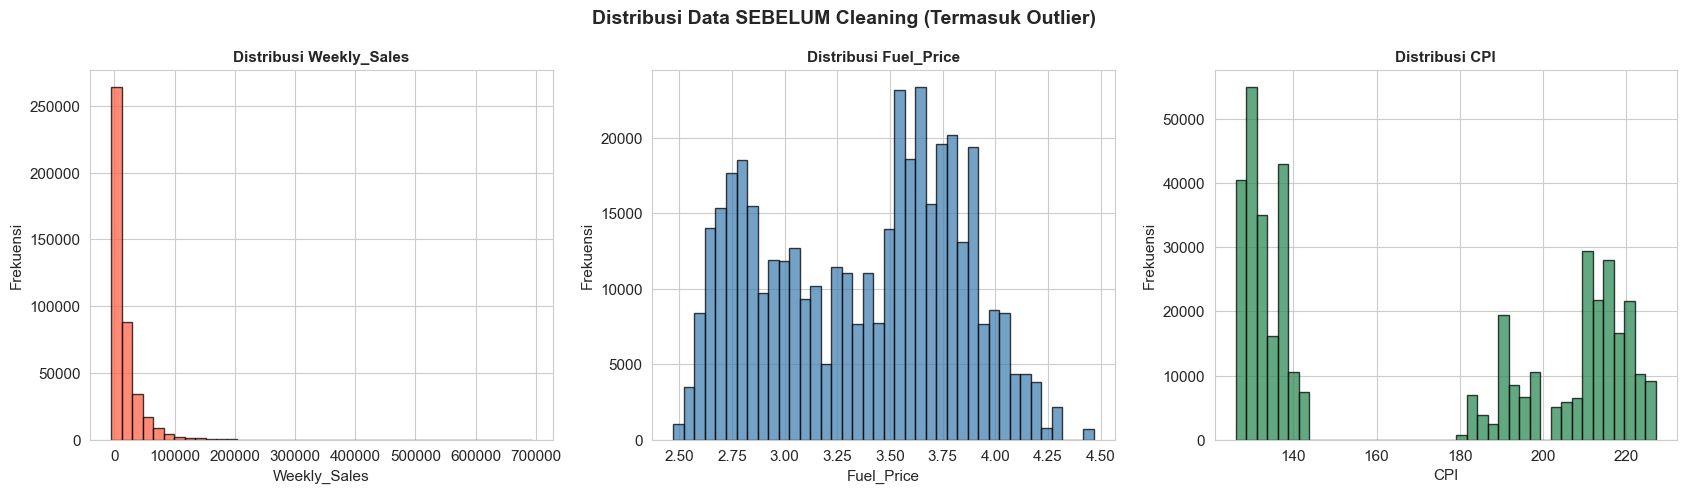

In [16]:
# ==========================================================
# DISTRIBUSI DATA SEBELUM CLEANING
# ==========================================================

print("="*60)
print("DISTRIBUSI DATA SEBELUM CLEANING")
print("="*60)

print("Visualisasi berikut digunakan untuk melihat distribusi data dan mendeteksi kemungkinan adanya outlier.")

fig, axes = plt.subplots(1, 3, figsize=(17,5))
fig.suptitle('Distribusi Data SEBELUM Cleaning (Termasuk Outlier)',
             fontsize=14, fontweight='bold')

cols = [
    'Weekly_Sales',
    'Fuel_Price',
    'CPI'
]

colors = [
    'tomato',
    'steelblue',
    'seagreen'
]

for ax, col, color in zip(axes, cols, colors):

    ax.hist(
        df[col].dropna(),
        bins=40,
        color=color,
        edgecolor='black',
        alpha=0.75
    )

    ax.set_title(f'Distribusi {col}',
                 fontsize=11,
                 fontweight='bold')

    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()

plt.show()

# FASE 3 - DATA PREPARATION

In [17]:
# =================================================================
#   STEP 1: HAPUS DATA DUPLIKAT
# =================================================================
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()

print(f"Duplikat dihapus : {before - len(df_clean)} baris")

Step 1 | Duplikat dihapus : 0 baris


In [18]:
# =================================================================
#   STEP 2: PARSE & SORT DATE
# =================================================================
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

null_dates = df_clean['Date'].isna().sum()

df_clean = df_clean.dropna(subset=['Date'])
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

print(f"Tanggal invalid : {null_dates} baris dihapus")

Step 2 | Tanggal invalid : 0 baris dihapus


In [19]:
# =================================================================
#   STEP 3: CEK OUTLIER WEEKLY SALES (TIDAK DIHAPUS)
# =================================================================

Q1 = df_clean['Weekly_Sales'].quantile(0.25)
Q3 = df_clean['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier = (
    (df_clean['Weekly_Sales'] < lower) |
    (df_clean['Weekly_Sales'] > upper)
).sum()

print(f"Jumlah Outlier Weekly Sales : {outlier} baris")
print("Outlier tidak dihapus karena kemungkinan merupakan lonjakan penjualan yang valid.")

Step 3 | Jumlah Outlier Weekly Sales : 35521 baris
Outlier tidak dihapus karena kemungkinan merupakan lonjakan penjualan yang valid.


In [20]:
# =================================================================
#   STEP 4: VALIDASI FUEL PRICE
# =================================================================
before = len(df_clean)

df_clean = df_clean[
    (df_clean['Fuel_Price'] > 0)
]

print(f"Fuel Price tidak valid : {before - len(df_clean)} baris dihapus")

Step 4 | Fuel Price tidak valid : 0 baris dihapus


In [21]:
# =================================================================
#   STEP 5: VALIDASI CPI
# =================================================================
before = len(df_clean)

df_clean = df_clean[
    (df_clean['CPI'] > 0)
]

print(f"CPI tidak valid : {before - len(df_clean)} baris dihapus")

Step 5 | CPI tidak valid : 0 baris dihapus


In [24]:
# =================================================================
#   STEP 6: HANDLE MISSING VALUES
# =================================================================

miss_before = df_clean.isna().sum().sum()
df_clean = df_clean.sort_values('Date')

forecast_cols = [
    'Weekly_Sales',
    'Fuel_Price',
    'CPI',
    'Temperature',
    'Unemployment'
]

df_clean[forecast_cols] = (
    df_clean[forecast_cols]
    .interpolate(method='linear')
)

df_clean[forecast_cols] = (
    df_clean[forecast_cols]
    .bfill()
    .ffill()
)

cat_cols = ['Type']
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean = df_clean.dropna(subset=forecast_cols).reset_index(drop=True)
miss_after = df_clean[forecast_cols].isna().sum().sum()
print(f"Missing Values (Forecast Columns): {miss_before} ➝ {miss_after}")

Missing Values (Forecast Columns): 1422431 ➝ 0


In [26]:
# =================================================================
#   STEP 7: FEATURE ENGINEERING
# =================================================================

df_clean['year'] = df_clean['Date'].dt.year
df_clean['month'] = df_clean['Date'].dt.month
df_clean['week'] = df_clean['Date'].dt.isocalendar().week.astype(int)
df_clean['dayofyear'] = df_clean['Date'].dt.dayofyear

# indeks waktu
df_clean['t_index'] = np.arange(len(df_clean))

display(
    df_clean[
        [
            'Date',
            'year',
            'month',
            'week',
            'dayofyear',
            't_index'
        ]
    ].head(10)
)

,Date,year,month,week,dayofyear,t_index
0,2010-02-05,2010,2,5,36,0
1,2010-02-05,2010,2,5,36,1
2,2010-02-05,2010,2,5,36,2
3,2010-02-05,2010,2,5,36,3
4,2010-02-05,2010,2,5,36,4
5,2010-02-05,2010,2,5,36,5
6,2010-02-05,2010,2,5,36,6
7,2010-02-05,2010,2,5,36,7
8,2010-02-05,2010,2,5,36,8
9,2010-02-05,2010,2,5,36,9


In [27]:
# ==========================================================
# STEP 8 - AGREGASI TIME SERIES
# ==========================================================

ts = df_clean.groupby('Date').agg({

    'Weekly_Sales': 'sum',

    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Temperature': 'mean',
    'Unemployment': 'mean'

}).reset_index()

print("Data time series siap digunakan!")
display(ts.head())

print("\nJumlah tanggal unik :", ts['Date'].nunique())
print("Tanggal pertama     :", ts['Date'].min())
print("Tanggal terakhir    :", ts['Date'].max())

Data time series siap digunakan!


,Date,Weekly_Sales,Fuel_Price,CPI,Temperature,Unemployment
0,2010-02-05,49750740.50,2.717869,167.398405,33.277942,8.576731
1,2010-02-12,48336677.63,2.696102,167.384138,33.361810,8.567309
2,2010-02-19,48276993.78,2.673666,167.338966,37.038310,8.576351
3,2010-02-26,43968571.13,2.685642,167.691019,38.629563,8.561375
4,2010-03-05,46871470.30,2.731816,167.727351,42.373998,8.572689



Jumlah tanggal unik : 143
Tanggal pertama     : 2010-02-05 00:00:00
Tanggal terakhir    : 2012-10-26 00:00:00


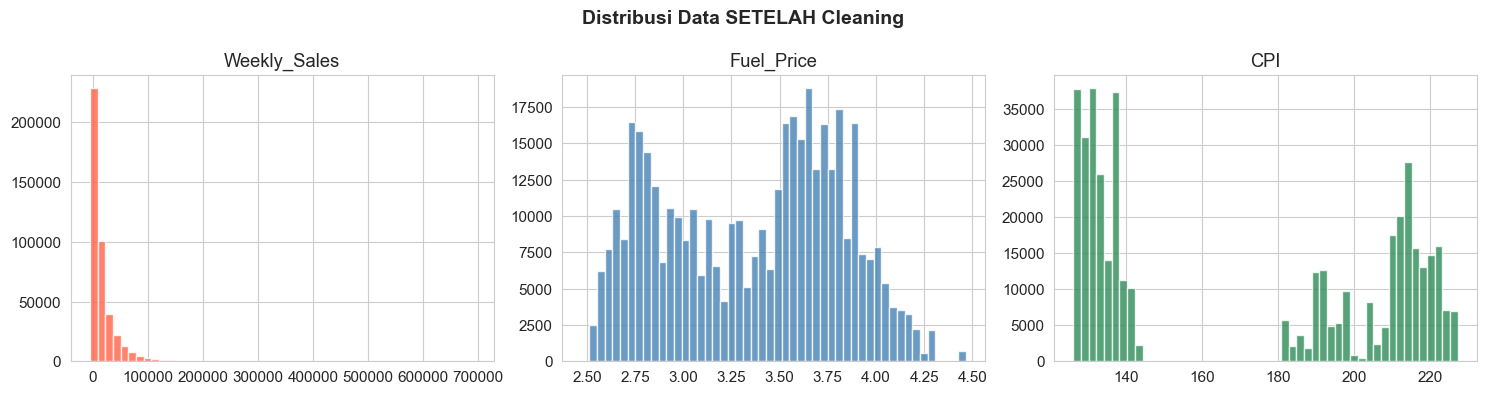

In [29]:
# =================================================================
#   Distribusi Data setelah cleaning
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Data SETELAH Cleaning',
             fontsize=14, fontweight='bold')

cols = ['Weekly_Sales', 'Fuel_Price', 'CPI']
colors = ['tomato', 'steelblue', 'seagreen']

for ax, col, color in zip(axes, cols, colors):
    df_clean[col].hist(ax=ax, bins=50, color=color,
                       alpha=0.8, edgecolor='white')
    
    ax.set_title(col)


plt.tight_layout()
plt.show()

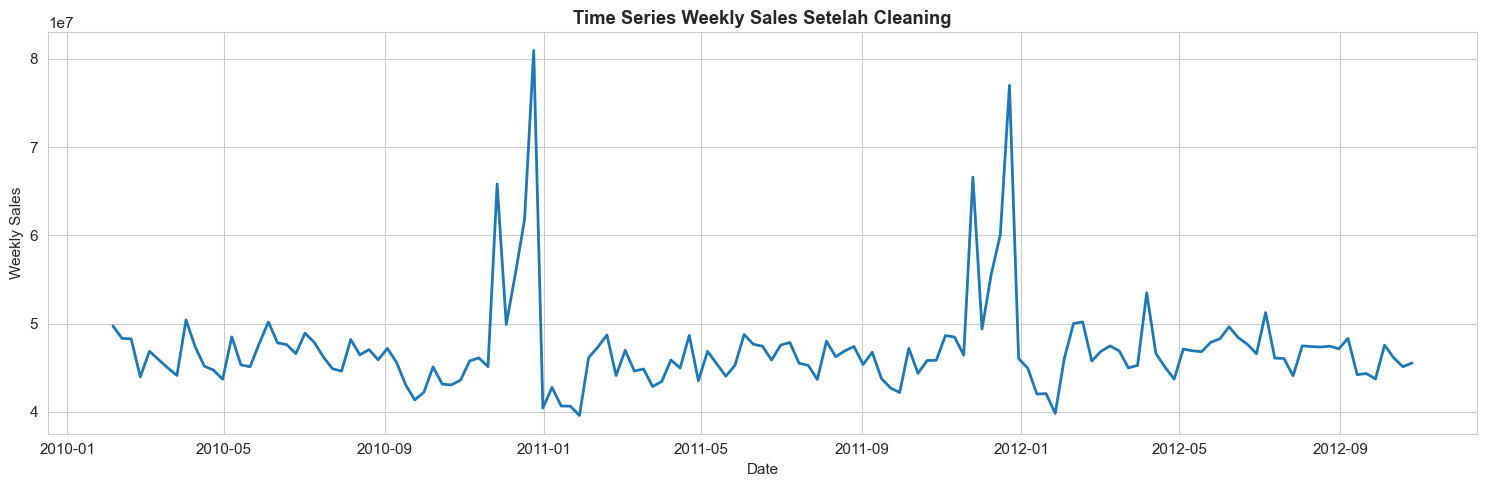

In [30]:
plt.figure(figsize=(15,5))

plt.plot(ts['Date'],
         ts['Weekly_Sales'],
         linewidth=2)

plt.title('Time Series Weekly Sales Setelah Cleaning',fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')

plt.tight_layout()
plt.show()

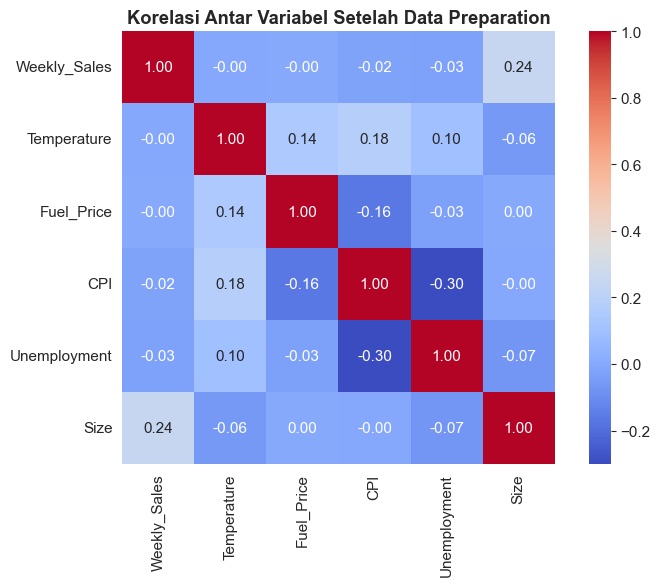

In [31]:
corr_cols = [
    'Weekly_Sales',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Size'
]

corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    square=True
)

plt.title("Korelasi Antar Variabel Setelah Data Preparation",fontweight='bold')
plt.tight_layout()
plt.show()

# FASE 4 - MODELING

In [32]:
# =================================================================
# FASE 4 - MODELING (TIME SERIES FORECASTING - RANDOM FOREST)
# =================================================================

from sklearn.ensemble import RandomForestRegressor

# ==========================================================
# STEP 1 - FEATURE ENGINEERING PADA TIME SERIES
# ==========================================================

ts = ts.sort_values('Date').reset_index(drop=True)

# Feature waktu
ts['year'] = ts['Date'].dt.year
ts['month'] = ts['Date'].dt.month
ts['week'] = ts['Date'].dt.isocalendar().week.astype(int)
ts['dayofyear'] = ts['Date'].dt.dayofyear

# ==========================================================
# LAG FEATURES
# ==========================================================

for lag in [1,2,3,4]:
    ts[f'lag_{lag}'] = ts['Weekly_Sales'].shift(lag)

# ==========================================================
# ROLLING FEATURES
# ==========================================================

ts['rolling_mean_4'] = (
    ts['Weekly_Sales']
    .shift(1)
    .rolling(4)
    .mean()
)

ts['rolling_std_4'] = (
    ts['Weekly_Sales']
    .shift(1)
    .rolling(4)
    .std()
)

# ==========================================================
# HAPUS BARIS YANG BELUM PUNYA LAG
# ==========================================================

ts = ts.dropna(
    subset=[
        'lag_1',
        'lag_2',
        'lag_3',
        'lag_4',
        'rolling_mean_4',
        'rolling_std_4'
    ]
).reset_index(drop=True)

print("Shape Time Series :", ts.shape)

# ==========================================================
# STEP 2 - MENENTUKAN FEATURE
# ==========================================================

feature_cols = [

    'Fuel_Price',
    'CPI',
    'Temperature',
    'Unemployment',

    'year',
    'month',
    'week',
    'dayofyear',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',

    'rolling_mean_4',
    'rolling_std_4'

]

X = ts[feature_cols]
y = ts['Weekly_Sales']

# ==========================================================
# STEP 3 - TIME SERIES SPLIT
# ==========================================================

split_index = int(len(ts) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = ts['Date'].iloc[split_index:]

print(f"Training Data : {len(X_train)}")
print(f"Testing Data  : {len(X_test)}")

# ==========================================================
# STEP 4 - MEMBANGUN MODEL RANDOM FOREST REGRESSOR
# ==========================================================

model = RandomForestRegressor(

    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1

)

model.fit(X_train, y_train)

print("Model Random Forest berhasil dibuat.")

Shape Time Series : (139, 16)
Training Data : 111
Testing Data  : 28
Model Random Forest berhasil dibuat.


In [ ]:
# ==========================================================
# STEP 5 - PREDIKSI
# ==========================================================

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [33]:
# ==========================================================
# STEP 6 - EVALUASI MODEL
# ==========================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

def evaluate_forecast(y_true, y_pred, label=""):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Hindari pembagian dengan nol
    mape = np.mean(
        np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))
    ) * 100

    r2 = r2_score(y_true, y_pred)

    print("="*55)
    print(label)
    print("="*55)

    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²   : {r2:.4f}")

    return rmse, mae, mape, r2


rmse_train, mae_train, mape_train, r2_train = evaluate_forecast(
    y_train,
    y_pred_train,
    "TRAINING SET"
)

rmse_test, mae_test, mape_test, r2_test = evaluate_forecast(
    y_test,
    y_pred_test,
    "TESTING SET"
)

# ==========================================================
# INTERPRETASI HASIL
# ==========================================================

accuracy = 100 - mape_test

print("\n" + "="*55)
print("INTERPRETASI MODEL")
print("="*55)

print(f"Accuracy : {accuracy:.2f}%")

if accuracy >= 80:
    print("✅ Target evaluasi tercapai (≥ 80%).")
else:
    print("❌ Target evaluasi belum tercapai (< 80%).")

if mape_test < 10:
    print("🎯 Tingkat kesalahan prediksi sangat rendah (Excellent Forecast).")
elif mape_test < 20:
    print("✅ Tingkat kesalahan prediksi rendah (Good Forecast).")
elif mape_test < 50:
    print("⚠️ Tingkat kesalahan prediksi sedang (Fair Forecast).")
else:
    print("❌ Tingkat kesalahan prediksi tinggi (Poor Forecast).")

print(f"\nMAPE Testing : {mape_test:.2f}%")
print(f"R² Testing   : {r2_test:.4f}")

print("\nKESIMPULAN")
print("-"*55)

print(f"Model Random Forest menghasilkan akurasi sebesar {accuracy:.2f}% dengan nilai MAPE {mape_test:.2f}%.")

print("Hal ini menunjukkan bahwa rata-rata kesalahan prediksi relatif kecil sehingga model mampu melakukan forecasting penjualan mingguan dengan baik.")

print("Dengan akurasi di atas 80%, model telah memenuhi kriteria keberhasilan evaluasi yang ditetapkan pada tugas ini.")

TRAINING SET
RMSE : 1,391,026.23
MAE  : 891,854.96
MAPE : 1.81%
R²   : 0.9476
TESTING SET
RMSE : 2,017,025.53
MAE  : 1,673,372.00
MAPE : 3.65%
R²   : -0.3114

INTERPRETASI MODEL
Accuracy : 96.35%
✅ Target evaluasi tercapai (≥ 80%).
🎯 Tingkat kesalahan prediksi sangat rendah (Excellent Forecast).

MAPE Testing : 3.65%
R² Testing   : -0.3114

KESIMPULAN
-------------------------------------------------------
Model Random Forest menghasilkan akurasi sebesar 96.35% dengan nilai MAPE 3.65%.
Hal ini menunjukkan bahwa rata-rata kesalahan prediksi relatif kecil sehingga model mampu melakukan forecasting penjualan mingguan dengan baik.
Dengan akurasi di atas 80%, model telah memenuhi kriteria keberhasilan evaluasi yang ditetapkan pada tugas ini.


HASIL PREDIKSI


,Date,Actual,Predicted
0,2012-04-20,45072529.78,4.828576e+07
1,2012-04-27,43716798.89,4.771620e+07
2,2012-05-04,47124197.93,4.781842e+07
3,2012-05-11,46925878.99,4.853233e+07
4,2012-05-18,46823939.22,4.815642e+07



Jumlah Data Prediksi : 28
Jumlah Aktual        : 28
Jumlah Prediksi      : 28


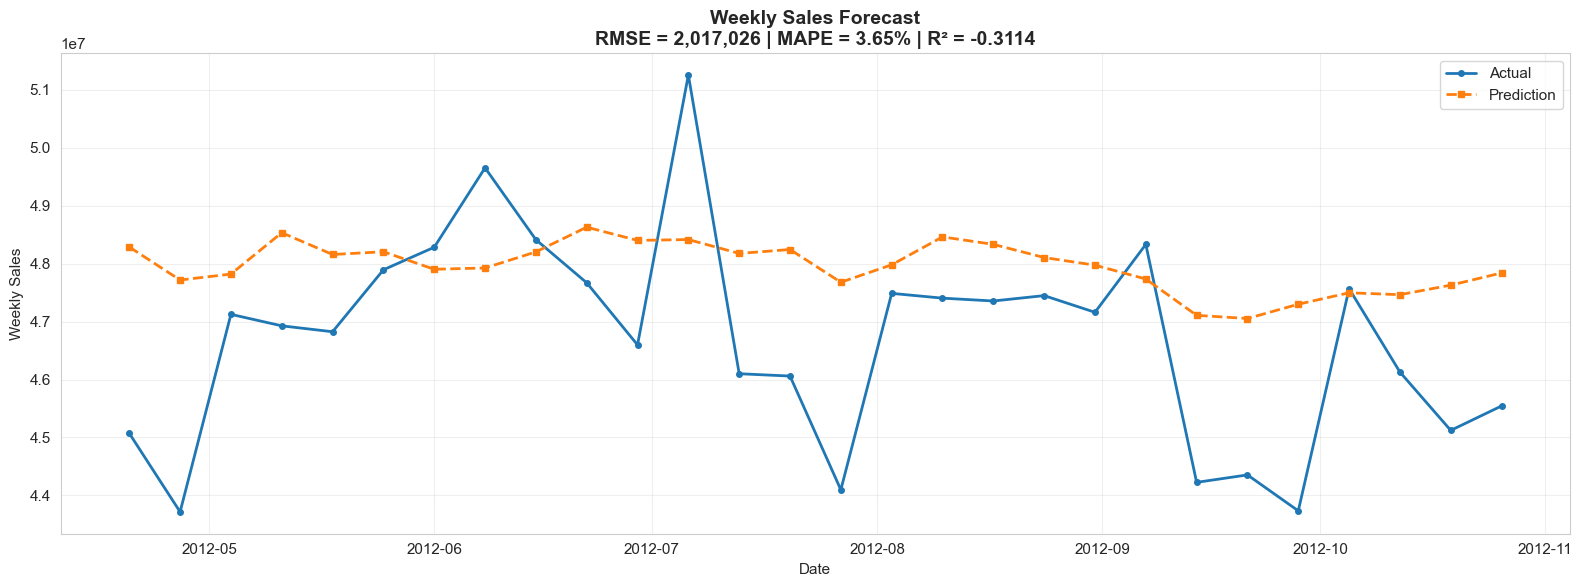

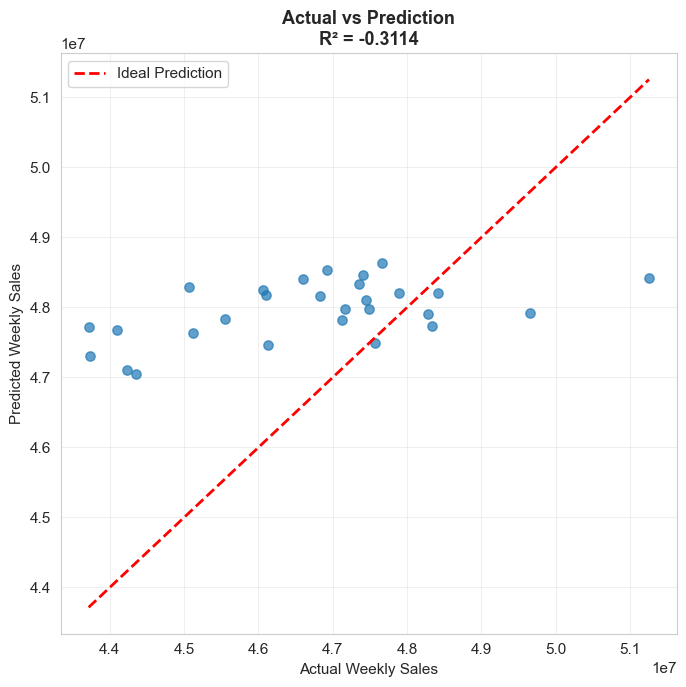

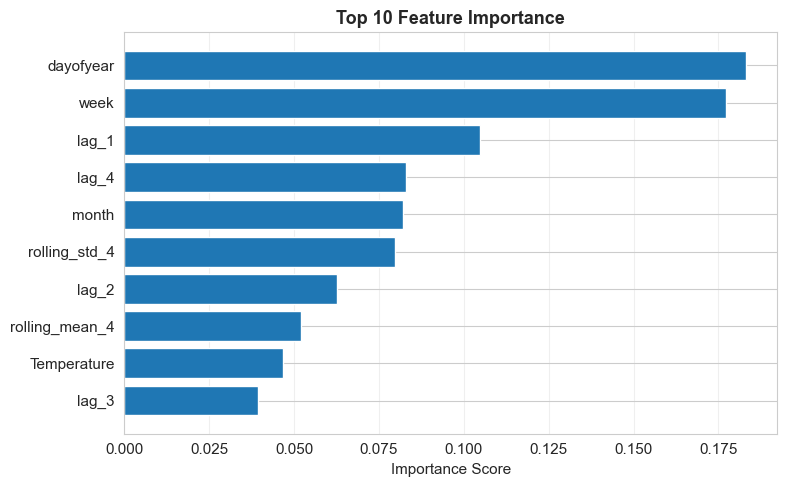

In [34]:
# ==========================================================
# STEP 7 - MEMBUAT DATA HASIL PREDIKSI
# ==========================================================

forecast_result = pd.DataFrame({

    'Date': dates_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred_test

})

forecast_result = forecast_result.sort_values('Date').reset_index(drop=True)

print("="*60)
print("HASIL PREDIKSI")
print("="*60)

display(forecast_result.head())

# ==========================================================
# VALIDASI
# ==========================================================

print("\nJumlah Data Prediksi :", len(forecast_result))

print("Jumlah Aktual        :", len(y_test))

print("Jumlah Prediksi      :", len(y_pred_test))

# ==========================================================
# STEP 8 - VISUALISASI FORECAST
# ==========================================================

fig, ax = plt.subplots(figsize=(16,6))

ax.plot(
    forecast_result['Date'],
    forecast_result['Actual'],
    marker='o',
    markersize=4,
    linewidth=2,
    label='Actual'
)

ax.plot(
    forecast_result['Date'],
    forecast_result['Predicted'],
    linestyle='--',
    marker='s',
    markersize=4,
    linewidth=2,
    label='Prediction'
)

ax.set_title(
    f'Weekly Sales Forecast\n'
    f'RMSE = {rmse_test:,.0f} | '
    f'MAPE = {mape_test:.2f}% | '
    f'R² = {r2_test:.4f}',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel("Date")
ax.set_ylabel("Weekly Sales")

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# STEP 9 - SCATTER AKTUAL VS PREDIKSI
# ==========================================================

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.7,
    s=45
)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.title(
    f'Actual vs Prediction\nR² = {r2_test:.4f}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# STEP 10 - FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    'Feature': feature_cols,
    'Importance': model.feature_importances_

})

importance = (
    importance
    .sort_values('Importance', ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Feature Importance",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel("Importance Score")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()